# Blog Generator with Routing, Research, Images + Refinement

The `reducer` step is now a **subgraph** that illustrates the blog before assembling it:

```
router -> (researcher | skip) -> orchestrator -> worker (fan-out) -> [ reducer subgraph ] -> refiner
                                                                     |
                                             art_director -> illustrator (fan-out) -> assembler
```

In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from typing import TypedDict, Annotated, List, Optional
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from pathlib import Path
import operator
import re
import os
import base64
import requests

In [3]:
load_dotenv()

True

In [12]:
class ResearchDecision(BaseModel):
    needs_research: bool = Field(
        ..., description="True if the blog needs current facts, data or citations from the web"
    )
    reason: str = Field(..., description="One short sentence explaining the decision")


class SearchQueries(BaseModel):
    queries: List[str] = Field(..., description="3-4 focused web search queries")


class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")


class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]


class ImageIdea(BaseModel):
    alt: str = Field(..., description="Accessible alt text, one short sentence")
    prompt: str = Field(
        ..., description="Image generation prompt: subject, style, palette, composition"
    )


class ImagePlan(BaseModel):
    hero: ImageIdea = Field(..., description="The banner image for the top of the blog")
    per_section: List[ImageIdea] = Field(
        ..., description="One idea per section, in the same order as the sections given"
    )


class ImageSpec(BaseModel):
    """An ImageIdea with its slot assigned by us, not by the model."""
    slot: int
    alt: str
    prompt: str

In [5]:
class State(TypedDict):
    topic: str
    needs_research: bool
    research_reason: str
    research: str
    sources: List[str]
    plan: Plan
    sections: Annotated[List[str], operator.add]
    images: List[dict]
    draft: str
    final: str


# The subgraph gets its own schema. It is invoked explicitly (see the `reducer`
# node) rather than dropped straight into the parent graph: if it shared the
# `sections` key it would echo those sections back, and the parent's
# operator.add reducer would append them a second time.
class ImageState(TypedDict):
    plan: Plan
    sections: List[str]
    image_specs: List[ImageSpec]
    images: Annotated[List[dict], operator.add]
    draft: str

In [6]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
search = TavilySearchResults(max_results=4)

IMAGE_MODEL = "gemini-3.1-flash-image"
IMAGE_DIR = Path("images")

/var/folders/5g/dm36k4d50wx6r_34fkk0t9900000gp/T/ipykernel_67435/760318161.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=4)


In [7]:
def generate_image(prompt: str, filename: str) -> dict:
    """Call the Gemini image model over REST. Returns {"path", "error"}.

    Never raises: a failed image must not kill the whole blog run.
    """
    IMAGE_DIR.mkdir(exist_ok=True)

    try:
        # key goes in a header, never the query string: a 4xx/5xx HTTPError message
        # echoes the request URL, which would leak the key into notebook output
        response = requests.post(
            f"https://generativelanguage.googleapis.com/v1beta/models/{IMAGE_MODEL}:generateContent",
            headers={"x-goog-api-key": os.environ["GOOGLE_API_KEY"]},
            json={"contents": [{"parts": [{"text": prompt}]}]},
            timeout=180,
        )
        response.raise_for_status()

        for part in response.json()["candidates"][0]["content"]["parts"]:
            if "inlineData" in part:
                path = IMAGE_DIR / filename
                path.write_bytes(base64.b64decode(part["inlineData"]["data"]))
                return {"path": str(path), "error": None}

        return {"path": None, "error": "response contained no image part"}

    except Exception as e:
        return {"path": None, "error": f"{type(e).__name__}: {str(e)[:160]}"}

In [8]:
def router(state: State) -> dict:

    decision = llm.with_structured_output(ResearchDecision).invoke(
        [
            SystemMessage(
                content=(
                    "Decide whether writing a blog on this topic needs live web research.\n\n"
                    "Ask: would a good blog on this topic state any figure, date, "
                    "version, price, or claim about the CURRENT state of the world?\n"
                    "  yes -> needs_research = true. Err on the side of true; stale "
                    "numbers are worse than a wasted search.\n"
                    "  no  -> needs_research = false. Reserve this for genuinely "
                    "timeless pieces: conceptual explainers, opinion, how-to, "
                    "creative writing, or advice with no factual claims to date."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    print(f"router: needs_research={decision.needs_research} ({decision.reason})")

    return {
        "needs_research": decision.needs_research,
        "research_reason": decision.reason,
    }


def route_research(state: State) -> str:
    return "researcher" if state["needs_research"] else "orchestrator"

In [9]:
def researcher(state: State) -> dict:

    queries = llm.with_structured_output(SearchQueries).invoke(
        [
            SystemMessage(
                content="Write 3-4 focused web search queries to research this blog topic."
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    # one Tavily call per query, de-duplicated by url
    seen, sources = set(), []
    for q in queries.queries:
        for hit in search.invoke({"query": q}):
            if hit["url"] in seen:
                continue
            seen.add(hit["url"])
            sources.append(hit)

    notes = "\n\n".join(
        f"[{i}] {s['title']}\n{s['url']}\n{s['content']}"
        for i, s in enumerate(sources, start=1)
    )

    return {"research": notes, "sources": [s["url"] for s in sources]}

In [13]:
def orchestrator(state: State) -> dict:

    research = state.get("research", "")

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a Blog Plan with 3-5 sections on the following topic. "
                    + (
                        "Ground the plan in the supplied research notes."
                        if research
                        else "Plan from general knowledge; no research was gathered."
                    )
                )
            ),
            HumanMessage(
                content=f"Topic: {state['topic']}"
                + (f"\n\nResearch notes:\n{research}" if research else "")
            ),
        ]
    )

    return {"plan": plan}

In [14]:
def distributer(state: State):
    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"],
                "research": state.get("research", ""),
            },
        )
        for task in state["plan"].tasks
    ]

In [15]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    research = payload["research"]

    if research:
        instruction = (
            "Write one clean Markdown section. Use only facts supported by the "
            "research notes. Cite sources inline as [1], [2] matching the notes."
        )
    else:
        instruction = (
            "Write one clean Markdown section from general knowledge. "
            "Do not fabricate statistics or citations."
        )

    section_md = llm.invoke(
        [
            SystemMessage(content=instruction),
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    + (f"Research notes:\n{research}\n\n" if research else "")
                    + "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

## The reducer subgraph

`art_director` plans one hero image plus one image per section, `illustrator` fans out
to generate them in parallel, and `assembler` interleaves them into the draft.

In [16]:
def art_director(state: ImageState) -> dict:

    headings = [s.strip().split("\n")[0].lstrip("# ").strip() for s in state["sections"]]
    listed = "\n".join(f"{i}. {h}" for i, h in enumerate(headings, start=1))

    plan = llm.with_structured_output(ImagePlan).invoke(
        [
            SystemMessage(
                content=(
                    "You are the art director for a blog post. Plan one hero image, plus "
                    f"exactly {len(headings)} section images -- one per section, in the "
                    "same order the sections are listed.\n"
                    "Every prompt must describe a clean editorial illustration: name the "
                    "subject, style, palette and composition. No text or lettering in the "
                    "image, no logos, no real identifiable people."
                )
            ),
            HumanMessage(
                content=f"Blog: {state['plan'].blog_title}\n\nSections:\n{listed}"
            ),
        ]
    )

    # we assign slots by position, so a short or long list can never mis-place an image
    specs = [ImageSpec(slot=0, alt=plan.hero.alt, prompt=plan.hero.prompt)]
    for i, idea in enumerate(plan.per_section[: len(headings)], start=1):
        specs.append(ImageSpec(slot=i, alt=idea.alt, prompt=idea.prompt))

    print(
        f"art_director: {len(headings)} sections -> {len(specs)} images "
        f"(model returned {len(plan.per_section)} section ideas)"
    )

    return {"image_specs": specs}


def distribute_images(state: ImageState):
    return [Send("illustrator", {"spec": spec}) for spec in state["image_specs"]]

In [17]:
def illustrator(payload: dict) -> dict:

    spec = payload["spec"]
    result = generate_image(spec.prompt, f"slot_{spec.slot}.png")

    if result["error"]:
        print(f"illustrator: slot {spec.slot} failed -> {result['error']}")

    return {
        "images": [
            {
                "slot": spec.slot,
                "alt": spec.alt,
                "prompt": spec.prompt,
                "path": result["path"],
                "error": result["error"],
            }
        ]
    }

In [18]:
def embed(image: dict) -> str:
    """Markdown for one image, or a visible placeholder if generation failed."""
    if image["path"]:
        return f"![{image['alt']}]({image['path']})"
    return f"> **[image unavailable]** {image['alt']}\n>\n> _prompt: {image['prompt']}_"


def assembler(state: ImageState) -> dict:

    by_slot = {img["slot"]: img for img in state["images"]}

    parts = [f"# {state['plan'].blog_title}"]

    if 0 in by_slot:
        parts.append(embed(by_slot[0]))

    for i, section in enumerate(state["sections"], start=1):
        parts.append(section.strip())
        if i in by_slot:
            parts.append(embed(by_slot[i]))

    return {"draft": "\n\n".join(parts) + "\n"}

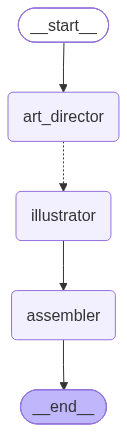

In [19]:
image_graph = StateGraph(ImageState)
image_graph.add_node("art_director", art_director)
image_graph.add_node("illustrator", illustrator)
image_graph.add_node("assembler", assembler)

image_graph.add_edge(START, "art_director")
image_graph.add_conditional_edges("art_director", distribute_images, ["illustrator"])
image_graph.add_edge("illustrator", "assembler")
image_graph.add_edge("assembler", END)

reducer_subgraph = image_graph.compile()

reducer_subgraph

In [20]:
def reducer(state: State) -> dict:
    """Parent-graph node that runs the image subgraph and hands back only
    the two keys the parent cares about."""

    result = reducer_subgraph.invoke(
        {"plan": state["plan"], "sections": state["sections"]}
    )

    return {"draft": result["draft"], "images": result["images"]}

In [21]:
def slugify(title: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_")
    return slug or "blog"


def refiner(state: State) -> dict:

    polished = llm.invoke(
        [
            SystemMessage(
                content=(
                    "Refine this blog draft. Remove repetition across sections, smooth the "
                    "transitions, and do not invent new facts.\n"
                    "Reproduce EXACTLY, character for character and in the same positions: "
                    "every inline [n] citation, every ![alt](path) image embed, and every "
                    "'> **[image unavailable]**' placeholder block. Never drop, reword, "
                    "reorder or renumber them.\n"
                    "Return the full blog in Markdown."
                )
            ),
            HumanMessage(content=state["draft"]),
        ]
    ).content.strip()

    sources = state.get("sources", [])
    if sources:
        refs = "\n".join(f"{i}. {url}" for i, url in enumerate(sources, start=1))
        final_md = f"{polished}\n\n## Sources\n\n{refs}\n"
    else:
        final_md = f"{polished}\n"

    Path(slugify(state["plan"].blog_title) + ".md").write_text(
        final_md, encoding="utf-8"
    )

    return {"final": final_md}

In [22]:
graph = StateGraph(State)
graph.add_node("router", router)
graph.add_node("researcher", researcher)
graph.add_node("orchestrator", orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer)   # <- wraps the image subgraph
graph.add_node("refiner", refiner)

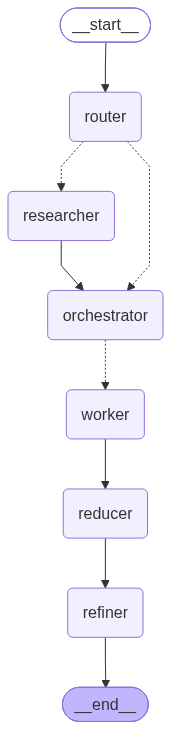

In [23]:
graph.add_edge(START, "router")
graph.add_conditional_edges("router", route_research, ["researcher", "orchestrator"])
graph.add_edge("researcher", "orchestrator")
graph.add_conditional_edges("orchestrator", distributer, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", "refiner")
graph.add_edge("refiner", END)

workflow = graph.compile()

workflow

In [ ]:
output = workflow.invoke({"topic": "Write a blog on Global Warming", "sections": []})

for img in sorted(output["images"], key=lambda i: i["slot"]):
    print(f"slot {img['slot']}: {img['path'] or img['error']}")

print()
print(output["final"][:1200])

In [ ]:
# stream with subgraphs=True to watch the inner nodes fire
for namespace, update in workflow.stream(
    {"topic": "Write a blog on what makes a good code review", "sections": []},
    subgraphs=True,
):
    where = ":".join(namespace) if namespace else "(parent)"
    print(f"{where:28s} {list(update)}")